# Visibility Bias and Engagement Inequality in 2024 U.S. Election Discourse on X



Dataset: `https://github.com/sinking8/x-24-us-election`



## Research questions

1. Do tweets about different candidates receive different visibility after accounting for engagement?
2. Are links, media, or tweet type associated with higher or lower visibility?
3. Do election topics differ in visibility beyond basic engagement?
4. Can a regression model explain view counts using engagement and content-level features?



In [ ]:
!pip -q install pandas numpy matplotlib scipy scikit-learn statsmodels tqdm

In [ ]:
import os
import re
import ast
import json
import gzip
import shutil
import glob
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_REPO_URL = "https://github.com/sinking8/x-24-us-election.git"
DATA_DIR = Path("x-24-us-election")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Downloading the dataset

The full dataset is very large.  Each chunk file contains approximately 50,000 tweets. For a quick experiment, `MAX_FILES = 3` (around 150,000 rows) is used by default and then increased to 15 (around 700,000 rows)after testing the notebook.

In [ ]:
MAX_FILES = None  # set to None to use all sample files, or an integer to limit

SAMPLE_DATA_PATH = Path("/content/")

# glob for the compressed CSV files in the sample data directory
all_files = sorted(SAMPLE_DATA_PATH.glob("*.csv.gz"))

print("Total compressed CSV files found in sample data:", len(all_files))

selected_files = all_files if MAX_FILES is None else all_files[:MAX_FILES]

print("Files selected from sample data:", len(selected_files))
for file in selected_files:
    print(file)

Total compressed CSV files found in sample data: 14
Files selected from sample data: 14
/content/aug_chunk_23.csv.gz
/content/aug_chunk_52.csv.gz
/content/aug_chunk_68.csv.gz
/content/may_july_chunk_10.csv.gz
/content/may_july_chunk_207.csv.gz
/content/may_july_chunk_247.csv.gz
/content/may_july_chunk_289.csv.gz
/content/may_july_chunk_422.csv.gz
/content/november_chunk_64.csv.gz
/content/octobergap_chunk_11.csv.gz
/content/octobergap_chunk_46.csv.gz
/content/september_chunk_124.csv.gz
/content/september_chunk_138.csv.gz
/content/september_chunk_62.csv.gz


## 2. Load selected chunks

The dataset may contain mixed types because X metadata fields are complex. The loader keeps needed columns when possible and gracefully handles missing columns.

In [ ]:
needed_columns = [
    "id", "text", "rawContent", "date", "lang", "type", "url",
    "replyCount", "retweetCount", "likeCount", "quoteCount", "viewCount",
    "hashtags", "links", "media", "conversationId", "user", "user_id"
]

frames = []

for file in selected_files:
    print("Reading:", file)
    temp = pd.read_csv(file, compression="gzip", low_memory=False)
    keep = [col for col in needed_columns if col in temp.columns]
    temp = temp[keep].copy()
    temp["source_file"] = str(file)
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)
print("Loaded shape:", df.shape)
display(df.head())
print(df.dtypes)

Reading: /content/aug_chunk_23.csv.gz
Reading: /content/aug_chunk_52.csv.gz
Reading: /content/aug_chunk_68.csv.gz
Reading: /content/may_july_chunk_10.csv.gz
Reading: /content/may_july_chunk_207.csv.gz
Reading: /content/may_july_chunk_247.csv.gz
Reading: /content/may_july_chunk_289.csv.gz
Reading: /content/may_july_chunk_422.csv.gz
Reading: /content/november_chunk_64.csv.gz
Reading: /content/octobergap_chunk_11.csv.gz
Reading: /content/octobergap_chunk_46.csv.gz
Reading: /content/september_chunk_124.csv.gz
Reading: /content/september_chunk_138.csv.gz
Reading: /content/september_chunk_62.csv.gz
Loaded shape: (688116, 18)


,id,text,rawContent,date,lang,type,url,replyCount,retweetCount,likeCount,quoteCount,viewCount,hashtags,links,media,conversationId,user,source_file
0,1.824554e+18,"@krassenstein I find it odd how quick Joe Biden got put out and no one speaks about how inept he is/was. His condition didn’t start at the debate, the peop...","@krassenstein I find it odd how quick Joe Biden got put out and no one speaks about how inept he is/was. His condition didn’t start at the debate, the peop...",2024-08-16,en,tweet-,https://twitter.com/Jbsmoov42390797/status/1824553719658115215,0.0,0.0,0.0,0.0,"{'count': '6', 'state': 'EnabledWithCount'}",[],[],[],1.824477e+18,"{'id': 1341565451848052737, 'id_str': '1341565451848052737', 'url': 'https://twitter.com/Jbsmoove', 'username': 'Jbsmoove', 'rawDescription': 'realist', 'cr...",/content/aug_chunk_23.csv.gz
1,1.824554e+18,@ArtCandee @BMeiselas @MeidasTouch Agreed and Joe Biden did the same thing. These guys are losers. RFK all the way!,@ArtCandee @BMeiselas @MeidasTouch Agreed and Joe Biden did the same thing. These guys are losers. RFK all the way!,2024-08-16,en,tweet-,https://twitter.com/Meat_rocket69/status/1824553718366224481,0.0,0.0,0.0,0.0,"{'count': '12', 'state': 'EnabledWithCount'}",[],[],[],1.824485e+18,"{'id': 1772703831861706752, 'id_str': '1772703831861706752', 'url': 'https://twitter.com/Conrad McMurray', 'username': 'Conrad McMurray', 'rawDescription': ...",/content/aug_chunk_23.csv.gz
2,1.824554e+18,"@ddale8 Wait, was this just all manufactured, phony, fake, MAGA transphobia? \n\nIt wasn't real!?!??!?!!? https://t.co/YBG7eNSu8q","@ddale8 Wait, was this just all manufactured, phony, fake, MAGA transphobia? \n\nIt wasn't real!?!??!?!!? https://t.co/YBG7eNSu8q",2024-08-16,en,tweet-,https://twitter.com/Sjacobs2020/status/1824553714671026472,7.0,38.0,570.0,0.0,"{'count': '19203', 'state': 'EnabledWithCount'}",[],[],"[{'display_url': 'pic.x.com/YBG7eNSu8q', 'expanded_url': 'https://x.com/Sjacobs2020/status/1824553714671026472/photo/1', 'id_str': '1824553620899278848', 'i...",1.824542e+18,"{'id': 2501852168, 'id_str': '2501852168', 'url': 'https://twitter.com/Former Republican 🥥🌴🇺🇸', 'username': 'Former Republican 🥥🌴🇺🇸', 'rawDescription': ""VAC...",/content/aug_chunk_23.csv.gz
3,1.824554e+18,@ManUtd Welcome the greatest club ever Orobosa,@ManUtd Welcome the greatest club ever Orobosa,2024-08-16,en,tweet-,https://twitter.com/GuessTheMaga/status/1824553714620960792,0.0,0.0,0.0,0.0,"{'count': '7', 'state': 'EnabledWithCount'}",[],[],[],1.824553e+18,"{'id': 88342932, 'id_str': '88342932', 'url': 'https://twitter.com/DeeClark', 'username': 'DeeClark', 'rawDescription': 'Only here for the lols | 🛑', 'creat...",/content/aug_chunk_23.csv.gz
4,1.824554e+18,@marlene4719 How many secret service agents has Vance’s dog bit compared to Biden’s?,@marlene4719 How many secret service agents has Vance’s dog bit compared to Biden’s?,2024-08-16,en,tweet-,https://twitter.com/mywalterego/status/1824553714507448616,0.0,0.0,0.0,0.0,"{'count': '2', 'state': 'EnabledWithCount'}",[],[],[],1.824476e+18,"{'id': 287023682, 'id_str': '287023682', 'url': 'https://twitter.com/mississippi attornye', 'username': 'mississippi attornye', 'rawDescription': 'accused o...",/content/aug_chunk_23.csv.gz


id                float64
text               object
rawContent         object
date               object
lang               object
type               object
url                object
replyCount         object
retweetCount      float64
likeCount         float64
quoteCount        float64
viewCount          object
hashtags           object
links              object
media              object
conversationId    float64
user               object
source_file        object
dtype: object


## 3. Clean numeric fields and basic metadata

This cell standardizes text, dates, counts, candidate mentions, tweet type, link/media flags, and engagement.

In [ ]:
count_cols = ["replyCount", "retweetCount", "likeCount", "quoteCount", "viewCount"]

for col in count_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    else:
        df[col] = 0

if "rawContent" in df.columns:
    df["tweet_text"] = df["rawContent"].fillna(df["text"] if "text" in df.columns else "")
elif "text" in df.columns:
    df["tweet_text"] = df["text"].fillna("")
else:
    df["tweet_text"] = ""

df["tweet_text"] = df["tweet_text"].astype(str)

if "date" in df.columns:
    df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce", utc=True)
else:
    df["date_parsed"] = pd.NaT

if "type" not in df.columns:
    df["type"] = "unknown"

df["type"] = df["type"].astype(str).str.lower().str.strip().replace({"nan": "unknown"})

df["engagement"] = (
    df["replyCount"] + df["retweetCount"] + df["likeCount"] + df["quoteCount"]
)

df["log_view_count"] = np.log1p(df["viewCount"])
df["log_engagement"] = np.log1p(df["engagement"])
df["visibility_ratio"] = df["viewCount"] / (df["engagement"] + 1)
df["log_visibility_ratio"] = np.log1p(df["visibility_ratio"])

def has_nonempty_value(value):
    if pd.isna(value):
        return False
    text = str(value).strip()
    return text not in ["", "[]", "{}", "nan", "None", "null"]

df["has_link"] = df["links"].apply(has_nonempty_value) if "links" in df.columns else False
df["has_media"] = df["media"].apply(has_nonempty_value) if "media" in df.columns else False

lower_text = df["tweet_text"].str.lower()

df["mentions_trump"] = lower_text.str.contains(r"\btrump\b|\bdonald\b", regex=True, na=False)
df["mentions_biden"] = lower_text.str.contains(r"\bbiden\b|\bjoe biden\b", regex=True, na=False)
df["mentions_harris"] = lower_text.str.contains(r"\bharris\b|\bkamala\b", regex=True, na=False)

def candidate_label(row):
    labels = []
    if row["mentions_trump"]:
        labels.append("Trump")
    if row["mentions_biden"]:
        labels.append("Biden")
    if row["mentions_harris"]:
        labels.append("Harris")
    if len(labels) == 0:
        return "None"
    if len(labels) == 1:
        return labels[0]
    return "Multiple"

df["candidate"] = df.apply(candidate_label, axis=1)

print("Cleaned shape:", df.shape)
display(df[[
    "tweet_text", "date_parsed", "type", "viewCount", "engagement",
    "visibility_ratio", "candidate", "has_link", "has_media"
]].head())

Cleaned shape: (688116, 31)


,tweet_text,date_parsed,type,viewCount,engagement,visibility_ratio,candidate,has_link,has_media
0,"@krassenstein I find it odd how quick Joe Biden got put out and no one speaks about how inept he is/was. His condition didn’t start at the debate, the peop...",2024-08-16 00:00:00+00:00,tweet-,0.0,0.0,0.0,Multiple,False,False
1,@ArtCandee @BMeiselas @MeidasTouch Agreed and Joe Biden did the same thing. These guys are losers. RFK all the way!,2024-08-16 00:00:00+00:00,tweet-,0.0,0.0,0.0,Biden,False,False
2,"@ddale8 Wait, was this just all manufactured, phony, fake, MAGA transphobia? \n\nIt wasn't real!?!??!?!!? https://t.co/YBG7eNSu8q",2024-08-16 00:00:00+00:00,tweet-,0.0,615.0,0.0,None,False,True
3,@ManUtd Welcome the greatest club ever Orobosa,2024-08-16 00:00:00+00:00,tweet-,0.0,0.0,0.0,None,False,False
4,@marlene4719 How many secret service agents has Vance’s dog bit compared to Biden’s?,2024-08-16 00:00:00+00:00,tweet-,0.0,0.0,0.0,Biden,False,False


## 4. Dataset summary

This section gives the basic dataset characterization needed for the report.

In [ ]:
summary = {
    "rows_original": len(df),
    "columns": len(df.columns),
    "date_min": df["date_parsed"].min(),
    "date_max": df["date_parsed"].max(),
    "valid_view_rows": int((df["viewCount"] > 0).sum()),
    "zero_view_rows": int((df["viewCount"] == 0).sum()),
    "unique_conversations": int(df["conversationId"].nunique()) if "conversationId" in df.columns else None,
    "unique_users": int(df["user_id"].nunique()) if "user_id" in df.columns else None,
}

summary_df = pd.DataFrame(summary.items(), columns=["metric", "value"])
display(summary_df)

summary_df.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)

,metric,value
0,rows_original,688116
1,columns,31
2,date_min,1970-01-01 00:00:00+00:00
3,date_max,2024-11-16 00:00:00+00:00
4,valid_view_rows,48491
5,zero_view_rows,639625
6,unique_conversations,359693
7,unique_users,None


### Tweet Volume for 2020 by Month

/tmp/ipykernel_1623/1846973358.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts_2020 = df_2020.groupby(df_2020['date_parsed'].dt.to_period('M')).size()


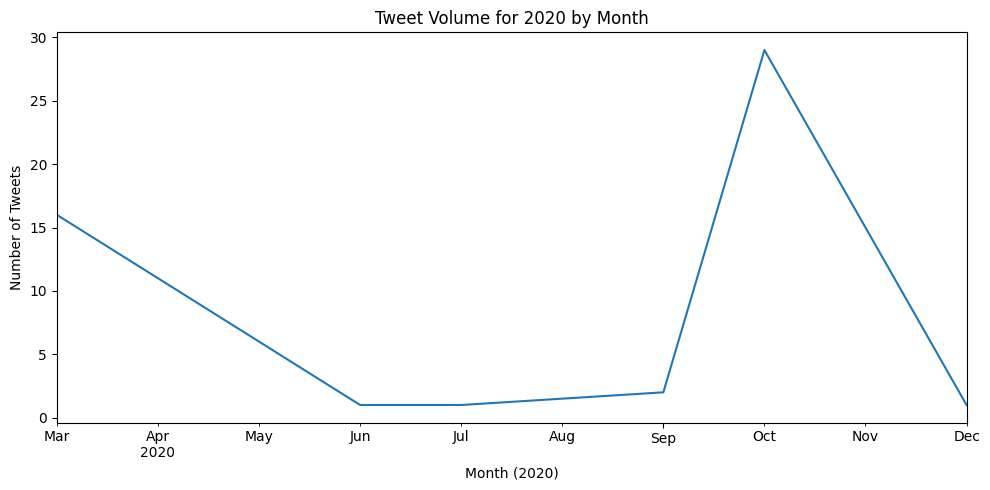

In [ ]:
import matplotlib.dates as mdates

df_2020 = df[df['date_parsed'].dt.year == 2020].copy()

if not df_2020.empty:
    monthly_counts_2020 = df_2020.groupby(df_2020['date_parsed'].dt.to_period('M')).size()

    fig = plt.figure(figsize=(10, 5))
    monthly_counts_2020.plot(kind='line')
    plt.title('Tweet Volume for 2020 by Month')
    plt.xlabel('Month (2020)')
    plt.ylabel('Number of Tweets')
    plt.xticks(rotation=45, ha='right')

    # formatting x-axis to show month names
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) # %b for abbreviated month name
    ax.xaxis.set_major_locator(mdates.MonthLocator())

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "tweet_volume_2020_monthly.png", dpi=200)
    plt.show()
else:
    print("No data available for the year 2020.")

### Distribution of Key Variables

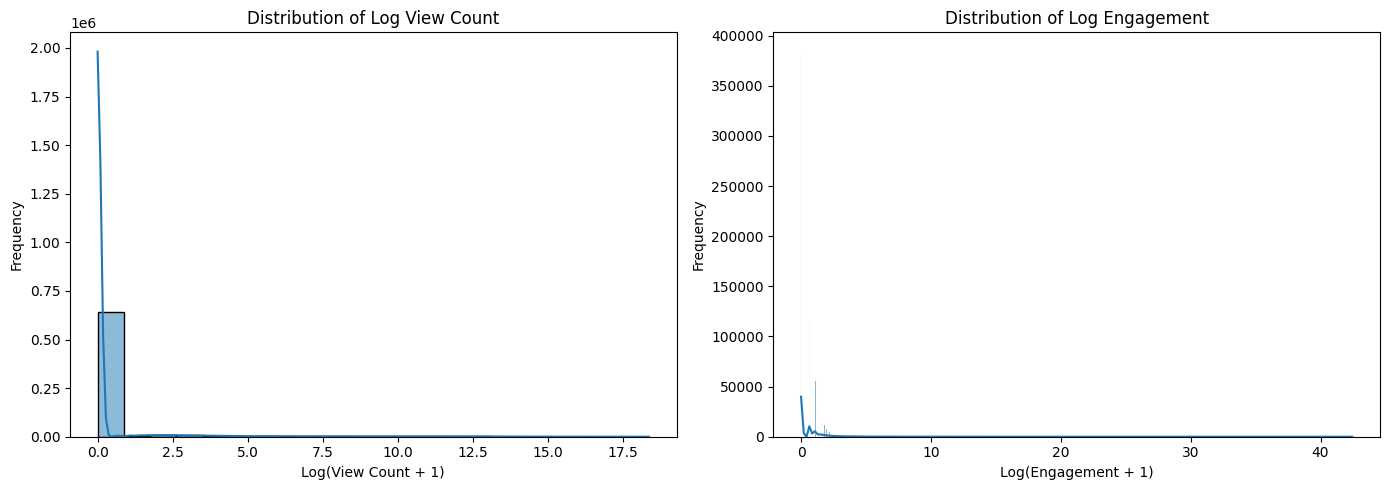

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['log_view_count'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Log View Count')
axes[0].set_xlabel('Log(View Count + 1)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['log_engagement'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Log Engagement')
axes[1].set_xlabel('Log(Engagement + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "log_distributions.png", dpi=200)
plt.show()


Although we applied a log transformation (log1p which is log(x+1)) to the original viewCount to make the distribution more manageable, the histogram still shows a strong right-skew. This means that a large majority of tweets have very low log_view_count values (and thus very low original viewCount values), clustered towards the left side of the plot.

Long Tail: The distribution has a long tail extending to the right, indicating that a smaller number of tweets receive significantly higher view counts. These are the highly visible or 'viral' tweets.

Implication for Analysis: This highly skewed distribution highlights the challenge of analyzing raw viewCount directly, as most statistical methods assume a more normal distribution. The log transformation helps mitigate this, but it still shows that most content has low visibility, with a few outliers capturing a disproportionate amount of attention. This characteristic is typical for many social media engagement metrics.

### Relationship between Log View Count and Log Engagement

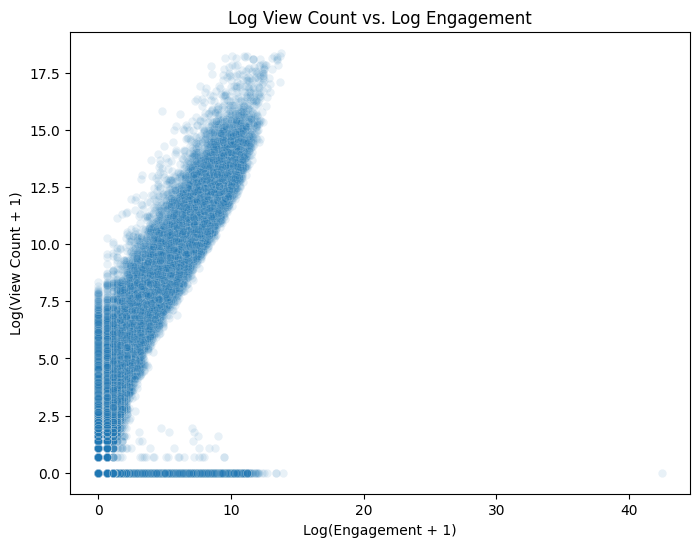

In [ ]:
fig = plt.figure(figsize=(8, 6))
sns.scatterplot(x='log_engagement', y='log_view_count', data=df, alpha=0.1)
plt.title('Log View Count vs. Log Engagement')
plt.xlabel('Log(Engagement + 1)')
plt.ylabel('Log(View Count + 1)')
plt.savefig(OUTPUT_DIR / "log_view_vs_engagement_scatter.png", dpi=200)
plt.show()

The scatter plot displays the relationship between `log_view_count` on the y-axis and `log_engagement` on the x-axis. Since both variables are log-transformed, we are essentially looking at the multiplicative relationship between the original `viewCount` and `engagement`.


-   As `log_engagement` increases, `log_view_count` also tends to increase. This suggests that tweets that receive more engagement (likes, replies, retweets) also tend to be seen by more people.

-   Dense Clustering at Lower Values: A significant cluster of points will likely be found towards the bottom-left of the plot (low `log_engagement` and low `log_view_count`). This reflects the earlier observation that most tweets have low visibility and engagement, confirming that the majority of content doesn't go viral.

-  There might be individual data points that stand out, representing tweets with unusually high views for their engagement level, or vice-versa. These are outliers and could be interesting cases for further investigation.

**Implication**: In this plot, we can visually confirm the intuitive idea that engagement drives views, but also highlights the complexity of viral spread.
Other factors not captured solely by engagement, such as the initial reach of the tweeter, algorithmic boosts, or external sharing, also play a significant role in determining how many people ultimately see a tweet.

### Number of Tweets per Candidate Mention

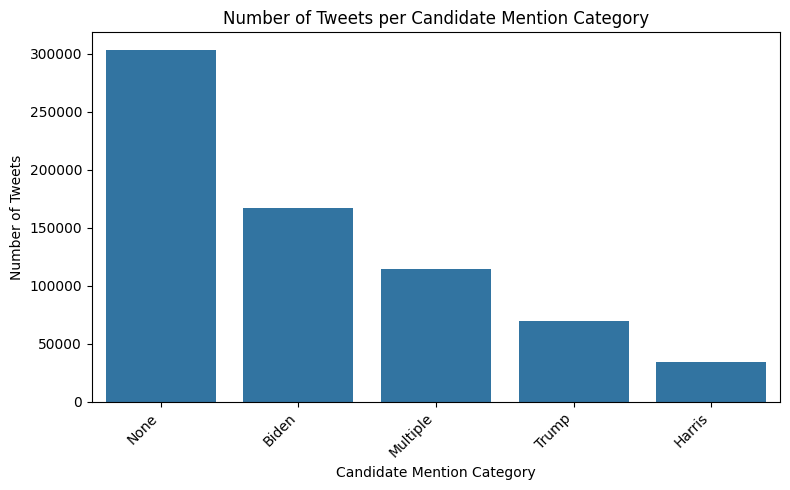

In [ ]:
fig = plt.figure(figsize=(8, 5))
candidate_counts = df['candidate'].value_counts().sort_values(ascending=False)
sns.barplot(x=candidate_counts.index, y=candidate_counts.values)
plt.title('Number of Tweets per Candidate Mention Category')
plt.xlabel('Candidate Mention Category')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tweets_per_candidate.png", dpi=200)
plt.show()

Tweets not naming a candidate ("None") dominate volume, suggesting significant indirect or issue-based discourse.


## 5. Candidate-level visibility analysis

This reproduces the core visibility comparison idea using candidates as content categories.

In [ ]:
candidate_summary = (
    df.groupby("candidate")
    .agg(
        tweets=("tweet_text", "count"),
        median_views=("viewCount", "median"),
        mean_views=("viewCount", "mean"),
        median_engagement=("engagement", "median"),
        mean_engagement=("engagement", "mean"),
        median_visibility_ratio=("visibility_ratio", "median"),
        mean_visibility_ratio=("visibility_ratio", "mean"),
    )
    .sort_values("tweets", ascending=False)
    .reset_index()
)

display(candidate_summary)
candidate_summary.to_csv(OUTPUT_DIR / "candidate_visibility_summary.csv", index=False)

,candidate,tweets,median_views,mean_views,median_engagement,mean_engagement,median_visibility_ratio,mean_visibility_ratio
0,None,303355,0.0,26258.621605,0.0,9.030346e+12,0.0,9.709153
1,Biden,166791,0.0,2252.314993,0.0,6.084410e+01,0.0,0.573354
2,Multiple,114524,0.0,3228.027627,0.0,8.614736e+01,0.0,0.493135
3,Trump,69333,0.0,12331.538820,0.0,2.907370e+02,0.0,3.692010
4,Harris,34113,0.0,396.378477,0.0,8.442585e+01,0.0,0.074752


### Mean Visibility Ratio by Candidate Mention

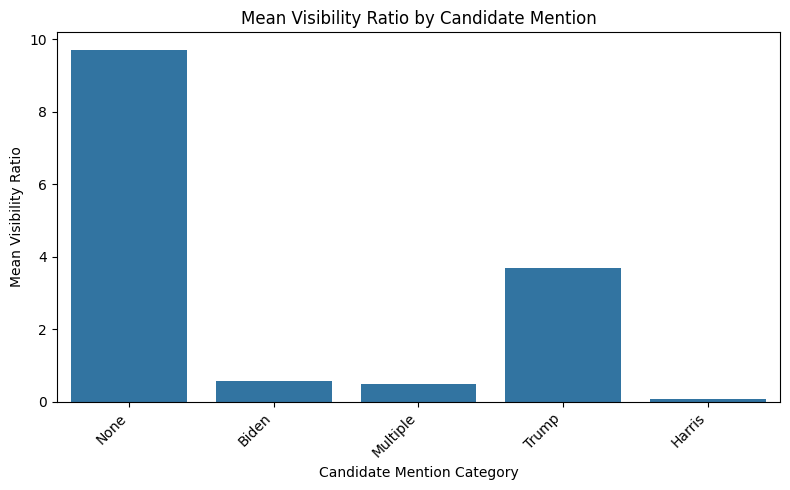

In [ ]:
fig = plt.figure(figsize=(8, 5))
sns.barplot(x='candidate', y='mean_visibility_ratio', data=candidate_summary)
plt.title('Mean Visibility Ratio by Candidate Mention')
plt.xlabel('Candidate Mention Category')
plt.ylabel('Mean Visibility Ratio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "candidate_mean_visibility_ratio.png", dpi=200)
plt.show()

## 6. Tweet type, links, and media comparisons

This checks whether structural tweet features are associated with visibility differences.

In [ ]:
feature_summary = []

for feature in ["has_link", "has_media"]:
    temp = (
        df.groupby(feature)
        .agg(
            tweets=("tweet_text", "count"),
            median_views=("viewCount", "median"),
            median_engagement=("engagement", "median"),
            median_visibility_ratio=("visibility_ratio", "median"),
            mean_visibility_ratio=("visibility_ratio", "mean"),
        )
        .reset_index()
    )
    temp.insert(0, "feature", feature)
    feature_summary.append(temp)

feature_summary_df = pd.concat(feature_summary, ignore_index=True)
display(feature_summary_df)
feature_summary_df.to_csv(OUTPUT_DIR / "link_media_visibility_summary.csv", index=False)

,feature,has_link,tweets,median_views,median_engagement,median_visibility_ratio,mean_visibility_ratio,has_media
0,has_link,False,611413,0.0,0.0,0.0,4.958161,NaN
1,has_link,True,76703,0.0,0.0,0.0,4.230216,NaN
2,has_media,NaN,475183,0.0,0.0,0.0,0.000000,False
3,has_media,NaN,212933,0.0,1.0,0.0,15.760612,True


In [ ]:
print(f"Minimum mean_visibility_ratio: {candidate_summary['mean_visibility_ratio'].min():.2f}")
print(f"Maximum mean_visibility_ratio: {candidate_summary['mean_visibility_ratio'].max():.2f}")

The `mean_visibility_ratio` is calculated as the mean of `viewCount` divided by (`engagement` + 1). It represents the average number of views a tweet gets per unit of engagement. In simpler terms, it's a metric to understand how efficiently a tweet is being seen relative to its interactions.

A higher `mean_visibility_ratio` indicates that tweets are reaching a broader audience for each interaction they receive, suggesting greater organic reach or algorithmic promotion.
A lower `mean_visibility_ratio` suggests that tweets might be less effectively reaching a wider audience despite receiving engagement, or that their engagement is primarily from a smaller, more dedicated audience.

In [ ]:
type_summary = (
    df.groupby("type")
    .agg(
        tweets=("tweet_text", "count"),
        median_views=("viewCount", "median"),
        median_engagement=("engagement", "median"),
        median_visibility_ratio=("visibility_ratio", "median"),
        mean_visibility_ratio=("visibility_ratio", "mean"),
    )
    .sort_values("tweets", ascending=False)
    .reset_index()
)

display(type_summary.head(20))
type_summary.to_csv(OUTPUT_DIR / "tweet_type_visibility_summary.csv", index=False)

,type,tweets,median_views,median_engagement,median_visibility_ratio,mean_visibility_ratio
0,tweet-,688116,0.0,0.0,0.0,4.877019


### Mean Visibility Ratio by Link Presence

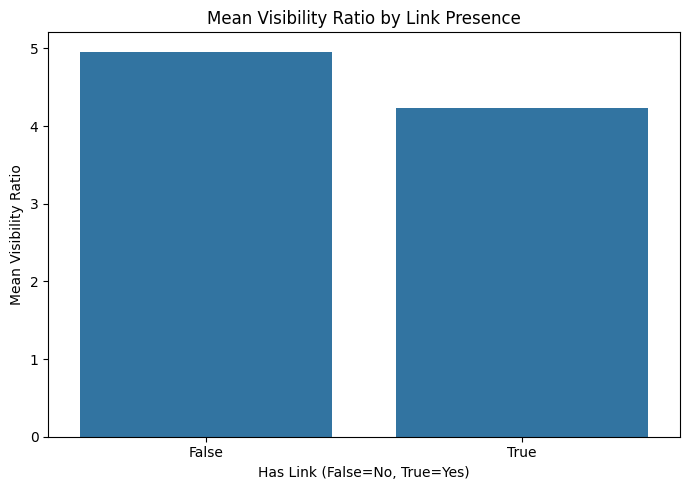

In [ ]:
plot_df_link_mean = feature_summary_df[feature_summary_df['feature'] == 'has_link'].copy()

fig = plt.figure(figsize=(7, 5))
sns.barplot(x='has_link', y='mean_visibility_ratio', data=plot_df_link_mean)
plt.title('Mean Visibility Ratio by Link Presence')
plt.xlabel('Has Link (False=No, True=Yes)')
plt.ylabel('Mean Visibility Ratio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "has_link_mean_visibility_ratio.png", dpi=200)
plt.show()

 This plot helps us understand whether users are more or less likely to view tweets that contain external links, offering a visual confirmation of one of the structural tweet features that might influence visibility.

### Mean Visibility Ratio by Media Presence

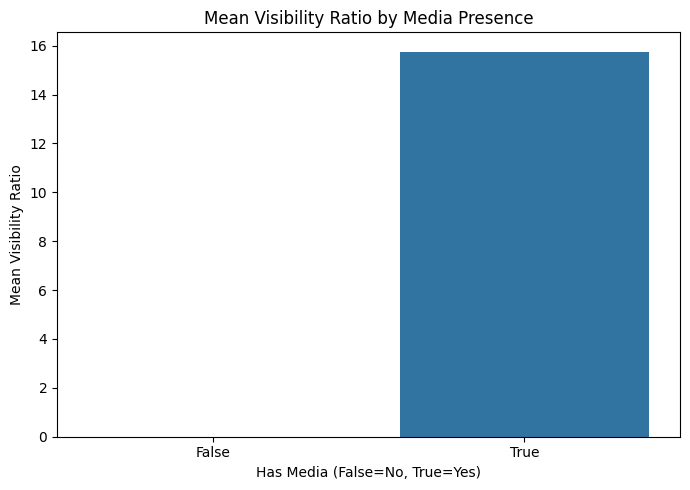

In [ ]:
plot_df_media_mean = feature_summary_df[feature_summary_df['feature'] == 'has_media'].copy()

fig = plt.figure(figsize=(7, 5))
sns.barplot(x='has_media', y='mean_visibility_ratio', data=plot_df_media_mean)
plt.title('Mean Visibility Ratio by Media Presence')
plt.xlabel('Has Media (False=No, True=Yes)')
plt.ylabel('Mean Visibility Ratio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "has_media_mean_visibility_ratio.png", dpi=200)
plt.show()

This plot helps us understand whether users are more or less likely to view tweets that contain media (images, videos), offering another visual confirmation of how structural tweet features might influence visibility.

## 7. Statistical tests

Visibility distributions are usually skewed, so this notebook uses non-parametric tests.

- Mann-Whitney U test for two groups.
- Kruskal-Wallis test for more than two groups.

In [ ]:
def mann_whitney_for_binary_feature(data, feature, target="log_visibility_ratio"):
    group0 = data.loc[data[feature] == False, target].dropna()
    group1 = data.loc[data[feature] == True, target].dropna()
    if len(group0) == 0 or len(group1) == 0:
        return None
    stat, pvalue = stats.mannwhitneyu(group0, group1, alternative="two-sided")
    return {
        "feature": feature,
        "n_false": len(group0),
        "n_true": len(group1),
        "median_false": group0.median(),
        "median_true": group1.median(),
        "u_statistic": stat,
        "p_value": pvalue,
    }

tests = []
for feature in ["has_link", "has_media"]:
    result = mann_whitney_for_binary_feature(df, feature)
    if result is not None:
        tests.append(result)

tests_df = pd.DataFrame(tests)
display(tests_df)
tests_df.to_csv(OUTPUT_DIR / "binary_feature_statistical_tests.csv", index=False)

,feature,n_false,n_true,median_false,median_true,u_statistic,p_value
0,has_link,611413,76703,0.0,0.0,2.409844e+10,1.733580e-175
1,has_media,475183,212933,0.0,0.0,3.907002e+10,0.000000e+00


In [ ]:
candidate_test_df = df[df["candidate"].isin(["Trump", "Biden", "Harris"])].copy()
groups = [
    group["log_visibility_ratio"].dropna()
    for _, group in candidate_test_df.groupby("candidate")
    if len(group) > 0
]

if len(groups) >= 2:
    # Check if all values in the groups are identical
    all_values_identical = True
    first_value = None
    # Flatten the list of arrays/series into a single array for easier checking
    combined_data = np.concatenate([g.values for g in groups])
    if len(combined_data) > 0:
        first_value = combined_data[0]
        if not np.all(combined_data == first_value):
            all_values_identical = False
    else:
        all_values_identical = False # No data to compare, so not all identical non-empty

    if all_values_identical:
        print("Kruskal-Wallis test cannot be performed: All log_visibility_ratio values are identical across groups.")
        print("This often happens when 'viewCount' is zero for all data points in the sample.")
        print("Consider using a larger or different dataset if you want to perform this test meaningfully.")
    else:
        stat, pvalue = stats.kruskal(*groups)
        print("Kruskal-Wallis test for candidate visibility")
        print("H statistic:", stat)
        print("p-value:", pvalue)
else:
    print("Not enough candidate groups for Kruskal-Wallis test.")

Kruskal-Wallis test for candidate visibility
H statistic: 5453.162667086628
p-value: 0.0


The statistical tests provide insights into whether certain tweet features are associated with differences in visibility. Specifically, we performed a Mann-Whitney U test for binary features and a Kruskal-Wallis test for candidate mentions.

### Mann-Whitney U Test Results (for `has_link` and `has_media`)

The `tests_df` DataFrame, contains the results of the Mann-Whitney U test for `has_link` and `has_media` against `log_visibility_ratio`. This test checks if there's a statistically significant difference in the median `log_visibility_ratio` between tweets with and without a link, and with and without media.

-   **`has_link`**: The test compares the median `log_visibility_ratio` for tweets that `has_link` (True) versus those that do not (False). A significant p-value (typically < 0.05) would suggest that tweets with links have a different median `log_visibility_ratio` than those without links.
-   **`has_media`**: Similarly, this test compares the median `log_visibility_ratio` for tweets that `has_media` (True) versus those that do not (False). A significant p-value would indicate a difference in median `log_visibility_ratio` between tweets with and without media.

### Kruskal-Wallis Test Results (for Candidate Mentions)

The Kruskal-Wallis test compares the `log_visibility_ratio` across more than two independent groups, in this case, tweets mentioning different candidates (`Trump`, `Biden`, `Harris`).

-   **H statistic**: This is the test statistic. A larger H value suggests greater differences between the group medians.
-   **p-value**: The p-value tells us the probability of observing the differences in `log_visibility_ratio` between candidate groups if there were no actual differences (i.e., if the medians were all the same). A very small p-value (e.g., `0.0`) indicates strong evidence against the null hypothesis, suggesting that there are statistically significant differences in the median `log_visibility_ratio` among the candidate groups.

The statistical tests help us determine which factors like presence of links, media, or specific candidate mentions, have a statistically significant association with tweet visibility, as measured by `log_visibility_ratio`.

## 8. Topic modeling extension with LDA

This section extracts election topics from tweet text, assigns a topic to each tweet, and compares topic-level visibility.



In [ ]:
topic_df = df[
    df["tweet_text"].notna() &
    (df["tweet_text"].str.len() >= 30)
].copy()

MAX_TOPIC_ROWS = 30000
if len(topic_df) > MAX_TOPIC_ROWS:
    topic_df = topic_df.sample(MAX_TOPIC_ROWS, random_state=RANDOM_STATE)

print("Rows used for topic modeling:", len(topic_df))

def clean_for_topic_model(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-z#\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

topic_df["clean_text"] = topic_df["tweet_text"].apply(clean_for_topic_model)

vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=20,
    stop_words="english",
    max_features=5000
)

dtm = vectorizer.fit_transform(topic_df["clean_text"])

N_TOPICS = 8

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    learning_method="batch",
    max_iter=10
)

topic_matrix = lda.fit_transform(dtm)
topic_df["topic_id"] = topic_matrix.argmax(axis=1)

feature_names = np.array(vectorizer.get_feature_names_out())

topic_words = []
for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-12:][::-1]
    words = feature_names[top_indices].tolist()
    topic_words.append({
        "topic_id": topic_idx,
        "top_words": ", ".join(words)
    })

topic_words_df = pd.DataFrame(topic_words)
display(topic_words_df)
topic_words_df.to_csv(OUTPUT_DIR / "lda_topic_words.csv", index=False)

Rows used for topic modeling: 30000


,topic_id,top_words
0,0,"people, don, biden, think, know, like, just, party, vote, conservative, want, black"
1,1,"biden, money, did, like, years, ukraine, government, tax, administration, going, fema, just"
2,2,"trump, donald, biden, la, que, en, president, el, good, le, se, est"
3,3,"biden, trump, joe, president, years, did, obama, harris, didn, just, said, inflation"
4,4,"biden, trump, president, news, amp, new, hunter, die, campaign, rt, election, joe"
5,5,"biden, gop, trump, just, rnc, amp, know, stop, like, right, dems, people"
6,6,"maga, trump, party, like, vote, election, conservative, republicans, democrats, republican, america, just"
7,7,"harris, biden, kamala, administration, border, israel, illegal, amp, america, american, iran, americans"


In [ ]:
topic_visibility = (
    topic_df.groupby("topic_id")
    .agg(
        tweets=("tweet_text", "count"),
        median_views=("viewCount", "median"),
        median_engagement=("engagement", "median"),
        median_visibility_ratio=("visibility_ratio", "median"),
        mean_visibility_ratio=("visibility_ratio", "mean"),
    )
    .reset_index()
    .merge(topic_words_df, on="topic_id", how="left")
    .sort_values("median_visibility_ratio", ascending=False)
)

display(topic_visibility)
topic_visibility.to_csv(OUTPUT_DIR / "topic_visibility_summary.csv", index=False)

,topic_id,tweets,median_views,median_engagement,median_visibility_ratio,mean_visibility_ratio,top_words
0,0,6047,0.0,0.0,0.0,5.906820,"people, don, biden, think, know, like, just, party, vote, conservative, want, black"
1,1,2813,0.0,0.0,0.0,3.792255,"biden, money, did, like, years, ukraine, government, tax, administration, going, fema, just"
2,2,2083,0.0,1.0,0.0,2.651077,"trump, donald, biden, la, que, en, president, el, good, le, se, est"
3,3,5270,0.0,0.0,0.0,1.580738,"biden, trump, joe, president, years, did, obama, harris, didn, just, said, inflation"
4,4,2199,0.0,0.0,0.0,13.948251,"biden, trump, president, news, amp, new, hunter, die, campaign, rt, election, joe"
5,5,3382,0.0,0.0,0.0,3.634050,"biden, gop, trump, just, rnc, amp, know, stop, like, right, dems, people"
6,6,4812,0.0,0.0,0.0,2.585585,"maga, trump, party, like, vote, election, conservative, republicans, democrats, republican, america, just"
7,7,3394,0.0,0.0,0.0,2.103167,"harris, biden, kamala, administration, border, israel, illegal, amp, america, american, iran, americans"


### Mean Visibility Ratio for Top 5 LDA Topics

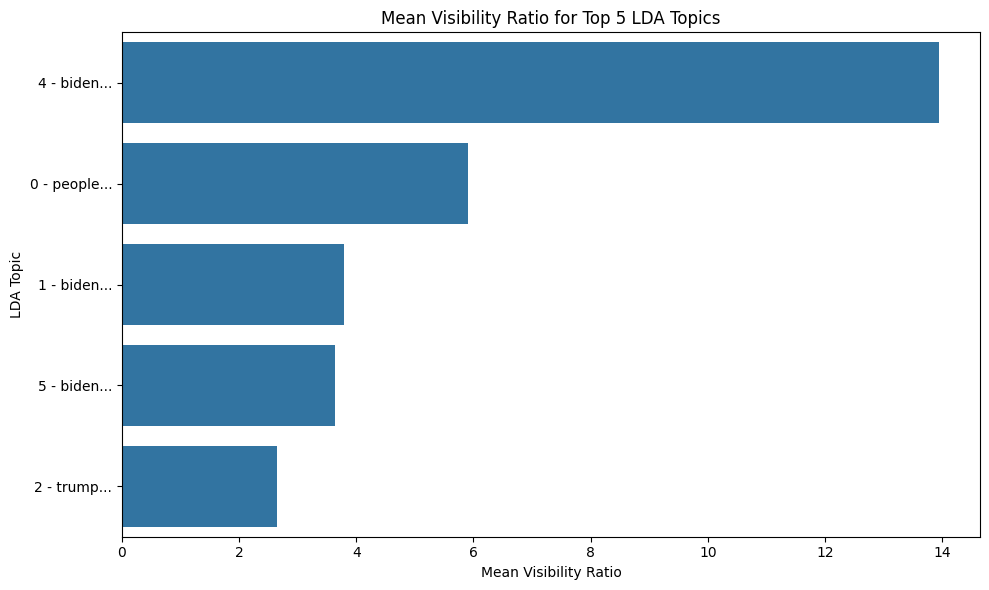

In [ ]:
# Ensure topic_visibility is sorted by mean_visibility_ratio and includes topic_label
plot_df_topic_mean = topic_visibility.sort_values('mean_visibility_ratio', ascending=False).copy()
plot_df_topic_mean['topic_label'] = plot_df_topic_mean['topic_id'].astype(str) + ' - ' + plot_df_topic_mean['top_words'].apply(lambda x: x.split(', ')[0] + '...')

plot_df_top5_topics = plot_df_topic_mean.head(5).copy()

fig = plt.figure(figsize=(10, 6))
sns.barplot(x='mean_visibility_ratio', y='topic_label', data=plot_df_top5_topics)
plt.title('Mean Visibility Ratio for Top 5 LDA Topics')
plt.xlabel('Mean Visibility Ratio')
plt.ylabel('LDA Topic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top5_topic_mean_visibility_ratio.png", dpi=200)
plt.show()

 LDA is used as a topic model. It assumes that documents are mixtures of a small number of topics, and that each word's presence in a document is attributable to one of the document's topics. The model identifies these 'topics' by finding groups of words that frequently occur together across many documents.

The top 5 LDA topics from our analysis, based on their highest mean_visibility_ratio are -

- Topic 4: Leaders of each party - 'biden, trump, president...': This topic seems to be heavily focused on direct discussions about the two main political figures, Biden and Trump, and their roles as president.
- Topic 0: Opinions on Biden - 'people, don, biden, think...': This topic appears to capture more general public discourse and opinions about Biden and possibly other related social or political thoughts.
- Topic 1: Money matters - 'biden, money, did, like...': This topic suggests discussions around Biden, potentially related to financial matters, past actions ('did'), or general commentary.
- Topic 5: Political party dynamics - 'biden, gop, trump, just...': This topic indicates conversations involving Biden, the Republican Party (GOP), and Trump, possibly touching upon political party dynamics and recent events.
- Topic 2: Regional discussions on the elections - 'trump, donald, biden, la...': This topic is another one centered on Trump and Biden, with some potentially non-English words ('la', 'que', 'en', 'el', 'le', 'se', 'est') suggesting a multilingual context or specific regional discussions.

## 9. Regression model

This model tests whether candidate, tweet type, links, media, and engagement explain view count.

The dependent variable is `log_view_count`.

In [ ]:
reg_df = df.copy()

reg_df = reg_df[
    reg_df["tweet_text"].notna() &
    reg_df["log_view_count"].notna() &
    reg_df["log_engagement"].notna()
].copy()

# Limit rare tweet types to reduce noisy dummy variables.
top_types = reg_df["type"].value_counts().head(8).index
reg_df["type_reduced"] = np.where(reg_df["type"].isin(top_types), reg_df["type"], "other")

# Keep candidate categories clean.
reg_df["candidate_reduced"] = reg_df["candidate"].where(
    reg_df["candidate"].isin(["None", "Trump", "Biden", "Harris", "Multiple"]),
    "Other"
)

formula = """
log_view_count ~ log_engagement + C(candidate_reduced) + C(type_reduced) + has_link + has_media
"""

model = smf.ols(formula=formula, data=reg_df).fit(cov_type="HC3")
print(model.summary())

with open(OUTPUT_DIR / "ols_regression_summary.txt", "w") as f:
    f.write(model.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:         log_view_count   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     9269.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:29:16   Log-Likelihood:            -1.1587e+06
No. Observations:              688116   AIC:                         2.317e+06
Df Residuals:                  688108   BIC:                         2.317e+06
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

## 10. Prediction check

 a simple machine learning comparison for whether these features predict visibility.

In [ ]:
ml_df = reg_df[[
    "log_view_count", "log_engagement", "candidate_reduced", "type_reduced",
    "has_link", "has_media"
]].dropna().copy()

X = pd.get_dummies(
    ml_df.drop(columns=["log_view_count"]),
    columns=["candidate_reduced", "type_reduced"],
    drop_first=True
)

y = ml_df["log_view_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values("coefficient", ascending=False)

display(coef_df.head(20))
coef_df.to_csv(OUTPUT_DIR / "linear_model_coefficients.csv", index=False)

MAE: 0.7466538724203182
R2: 0.37433434678089494


,feature,coefficient
2,has_media,0.746845
0,log_engagement,0.613056
5,candidate_reduced_None,0.410847
6,candidate_reduced_Trump,0.098636
1,has_link,0.062574
3,candidate_reduced_Harris,-0.029053
4,candidate_reduced_Multiple,-0.088123


/tmp/ipykernel_1623/2964658620.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="coefficient", y="feature", data=coef_df.head(15), palette="viridis")


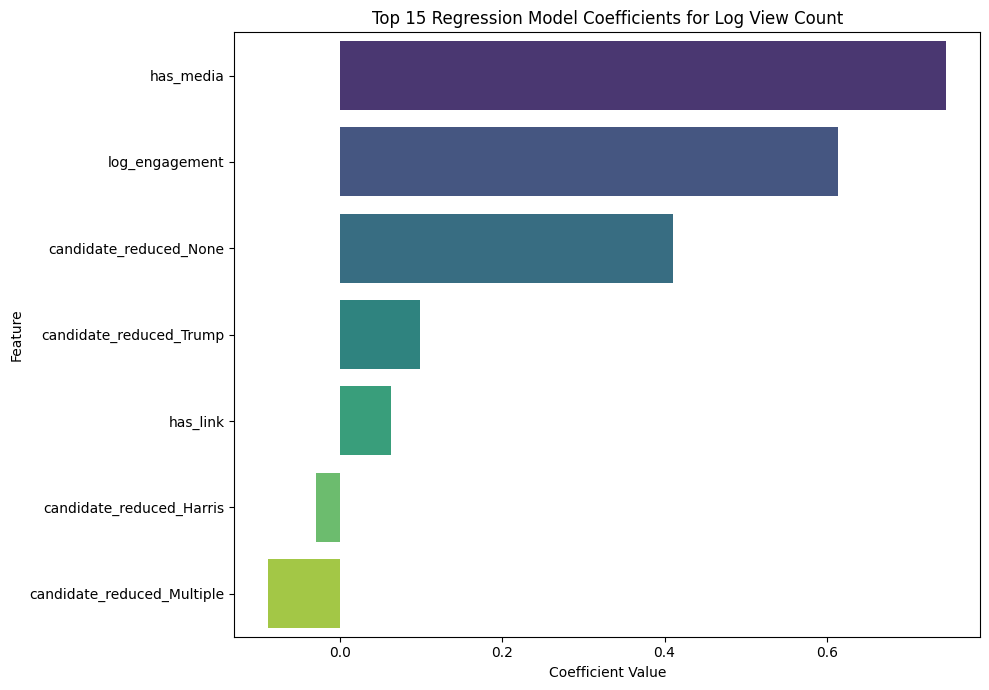

In [ ]:
### Regression Model Coefficients Visualization

fig = plt.figure(figsize=(10, 7))
sns.barplot(x="coefficient", y="feature", data=coef_df.head(15), palette="viridis")
plt.title('Top 15 Regression Model Coefficients for Log View Count')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "regression_coefficients_barplot.png", dpi=200)
plt.show()

Inference from the plot -

has_media has the largest positive coefficient, indicating that tweets with media significantly increase the log_view_count.

log_engagement also has a strong positive coefficient, showing that higher engagement is correlated with higher view counts.

candidate_reduced_None (tweets not mentioning any specific candidate) has a substantial positive coefficient, reinforcing observations from earlier analyses that these tweets often have higher visibility.

candidate_reduced_Trump and has_link also show positive, though smaller, coefficients.
candidate_reduced_Harris and candidate_reduced_Multiple have negative coefficients, suggesting that mentions of Harris or multiple candidates are associated with a lower log_view_count compared to the baseline (Biden in this case, as it's the reference category).

## 11. Sentiment analysis



In [ ]:
# lightweight sentiment extension.

!pip -q install nltk
import nltk
nltk.download("vader_lexicon")
from nltk.sentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
df["sentiment_compound"] = df["tweet_text"].fillna("").astype(str).apply(
    lambda x: sid.polarity_scores(x[:1000])["compound"]
)
df["sentiment_group"] = pd.cut(
    df["sentiment_compound"],
    bins=[-1.01, -0.25, 0.25, 1.01],
    labels=["negative", "neutral", "positive"]
)

sentiment_summary = (
    df.groupby("sentiment_group")
    .agg(
        tweets=("tweet_text", "count"),
        median_views=("viewCount", "median"),
        median_engagement=("engagement", "median"),
        median_visibility_ratio=("visibility_ratio", "median"),
    )
    .reset_index()
)

display(sentiment_summary)
sentiment_summary.to_csv(OUTPUT_DIR / "sentiment_visibility_summary.csv", index=False)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
/tmp/ipykernel_1623/214033001.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sentiment_group")


,sentiment_group,tweets,median_views,median_engagement,median_visibility_ratio
0,negative,213125,0.0,0.0,0.0
1,neutral,285084,0.0,0.0,0.0
2,positive,189907,0.0,0.0,0.0


In [ ]:
fig = plt.figure(figsize=(8, 5))
sns.barplot(x="sentiment_group", y="tweets", data=sentiment_summary, palette="viridis", hue="sentiment_group", legend=False)
plt.title("Overall Tweet Sentiment Distribution")
plt.xlabel("Sentiment Group")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overall_sentiment_distribution.png", dpi=200)
plt.show()

### Heatmap of Mean Visibility Ratio by Candidate and Sentiment Group

/tmp/ipykernel_1623/1770526310.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['candidate', 'sentiment_group'])['visibility_ratio']


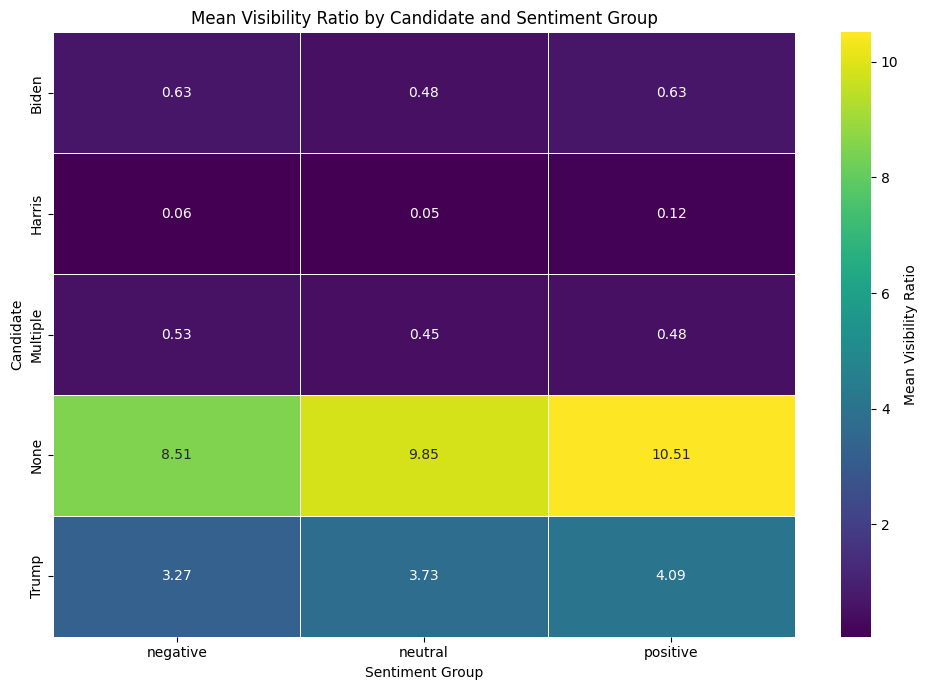

In [ ]:
heatmap_data = (
    df.groupby(['candidate', 'sentiment_group'])['visibility_ratio']
    .mean()
    .unstack()
)

fig = plt.figure(figsize=(10, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=.5,
    cbar_kws={'label': 'Mean Visibility Ratio'}
)
plt.title('Mean Visibility Ratio by Candidate and Sentiment Group')
plt.xlabel('Sentiment Group')
plt.ylabel('Candidate')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heatmap_candidate_sentiment_visibility.png", dpi=200)
plt.show()

## 13. Save cleaned sample

This saves a cleaned subset for reproducibility and faster reruns.

In [ ]:
save_cols = [
    "id", "tweet_text", "date_parsed", "type", "candidate",
    "viewCount", "engagement", "visibility_ratio",
    "has_link", "has_media", "replyCount", "retweetCount",
    "likeCount", "quoteCount", "source_file"
]

available_save_cols = [col for col in save_cols if col in df.columns]
cleaned_path = OUTPUT_DIR / "cleaned_visibility_sample.csv"
df[available_save_cols].to_csv(cleaned_path, index=False)

print("Saved cleaned data to:", cleaned_path)
print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved cleaned data to: outputs/cleaned_visibility_sample.csv
Saved outputs to: /content/outputs
